# Raw Template Matching: development experiment and evaluation

This notebook is the complete development interface for raw Template Matching. It verifies the manifest, runs or reloads all 139 development records, evaluates detections against XML annotations, and visualises class performance, runtime, thresholds, fragmentation, and representative images. It never selects validation or test rows.

In [2]:
import json
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = next(
    candidate
    for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / 'data' / 'dataset_split.csv').is_file()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from algorithms.common import load_image
from algorithms.evaluation import parse_voc_boxes
from algorithms.template_matching import detect_template_matching
from scripts.run_template_matching_development import (
    VALIDATION_CANDIDATES,
    evaluate_records,
    load_development_rows,
    summarise,
    write_results,
)

plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', 30)

## 1. Development baseline configuration (not frozen)

Development is used to implement and debug this baseline and to identify defensible candidate settings. Final parameter and matching-rule selection belongs to validation. Template Matching's intensity threshold is selected automatically for every difference image; it is an output, not a tuned hyperparameter. `IOU_THRESHOLD = 0.50` is only a provisional one-to-one diagnostic rule. The raw pipeline uses no blur, resizing, morphology, contour-area filtering, or region merging.

In [3]:
MANIFEST_PATH = PROJECT_ROOT / 'data' / 'dataset_split.csv'
RESULTS_PATH = PROJECT_ROOT / 'outputs' / 'metrics' / 'template_matching_development.csv'
SUMMARY_PATH = PROJECT_ROOT / 'outputs' / 'metrics' / 'template_matching_development_summary.json'
BOXES_DIR = PROJECT_ROOT / 'outputs' / 'metrics' / 'template_matching_development_boxes'
CORR_THRESHOLD = 0.65
BLOCK_SIZE = (32, 32)
STEP_SIZE = 16
IOU_THRESHOLD = 0.50
RUN_DEVELOPMENT = False  # Set True to recompute all 139 full-resolution images.

development_baseline = {
    'input': 'aligned reference and defective image pair',
    'shared_preprocessing': 'dimension validation and grayscale conversion',
    'comparison': 'cv2.matchTemplate (NCC)',
    'correlation_threshold': CORR_THRESHOLD,
    'block_size': BLOCK_SIZE,
    'step_size': STEP_SIZE,
    'contours': 'Direct extraction of bounding boxes from matching blocks',
    'post_processing': 'none',
    'evaluation_iou': IOU_THRESHOLD,
}
display(pd.Series(development_baseline, name='setting').to_frame())
display(pd.Series(VALIDATION_CANDIDATES, name='candidates').to_frame())

,setting
input,aligned reference and defective image pair
shared_preprocessing,dimension validation and grayscale conversion
comparison,cv2.matchTemplate (NCC)
threshold,0.68 fixed correlation threshold
contours,Direct extraction of bounding boxes from match...
post_processing,none
evaluation_iou,0.5


## 2. Manifest and development-split verification

,images
split,
development,139
validation,139
test,415


,development_images
defect_class,
missing_hole,23
mouse_bite,23
open_circuit,24
short_circuit,23
spur,23
spurious_copper,23


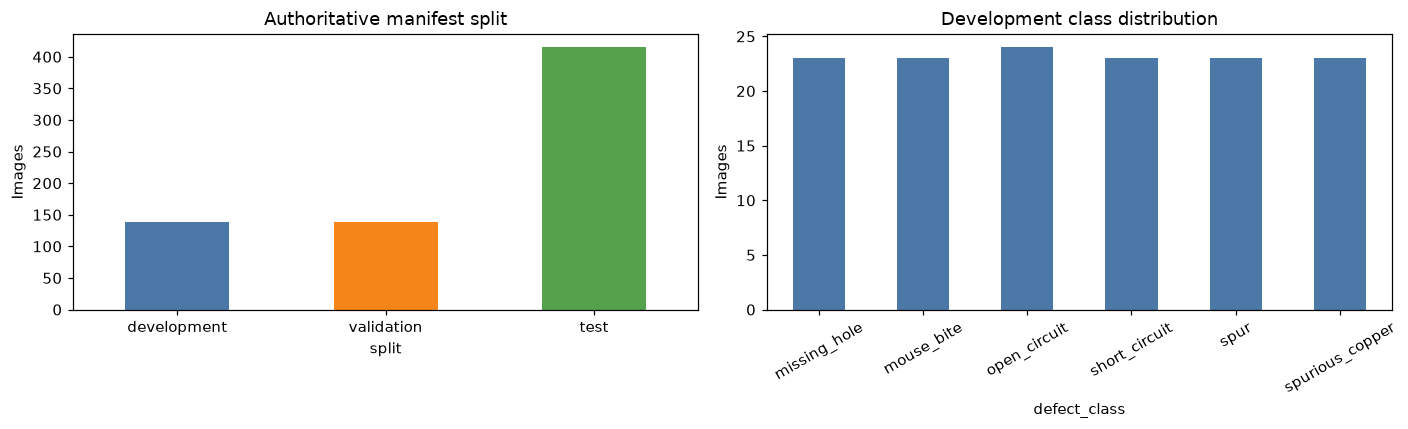

In [4]:
manifest_df = pd.read_csv(MANIFEST_PATH)
development_df = manifest_df.loc[manifest_df['split'].eq('development')].copy()

assert len(manifest_df) == 693
assert len(development_df) == 139
assert set(development_df['split']) == {'development'}
assert development_df['image_id'].is_unique

split_counts = manifest_df['split'].value_counts().reindex(
    ['development', 'validation', 'test']
)
class_counts = development_df['defect_class'].value_counts().sort_index()
display(split_counts.rename('images').to_frame())
display(class_counts.rename('development_images').to_frame())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
split_counts.plot.bar(ax=axes[0], color=['#4C78A8', '#F58518', '#54A24B'])
axes[0].set_title('Authoritative manifest split')
axes[0].set_ylabel('Images')
axes[0].tick_params(axis='x', rotation=0)
class_counts.plot.bar(ax=axes[1], color='#4C78A8')
axes[1].set_title('Development class distribution')
axes[1].set_ylabel('Images')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## 3. Execute or reload the development experiment

The existing verified outputs are loaded by default. Set `RUN_DEVELOPMENT = True` to rerun the complete full-resolution experiment. Complete unfiltered predicted boxes are stored in typed NumPy sidecars because raw Template Matching produced more than 25 million contours.

In [5]:
outputs_exist = RESULTS_PATH.is_file() and SUMMARY_PATH.is_file()
if RUN_DEVELOPMENT or not outputs_exist:
    development_rows = load_development_rows(MANIFEST_PATH)
    results = evaluate_records(
        development_rows,
        IOU_THRESHOLD,
        corr_threshold=CORR_THRESHOLD,
        block_size=BLOCK_SIZE,
        step_size=STEP_SIZE,
        workers=1,
        boxes_directory=BOXES_DIR,
    )
    summary = summarise(
        results, IOU_THRESHOLD, CORR_THRESHOLD, BLOCK_SIZE, STEP_SIZE
    )
    write_results(results, RESULTS_PATH)
    SUMMARY_PATH.parent.mkdir(parents=True, exist_ok=True)
    SUMMARY_PATH.write_text(
        json.dumps(summary, indent=2, sort_keys=True) + '\n',
        encoding='utf-8',
    )
    print('Development experiment completed and saved.')
else:
    print('Loading the existing verified development results.')

Loading the existing verified development results.


In [6]:
results_df = pd.read_csv(RESULTS_PATH)
summary = json.loads(SUMMARY_PATH.read_text(encoding='utf-8'))

assert len(results_df) == 139
assert set(results_df['split']) == {'development'}
assert set(results_df['status']) == {'success'}
assert summary['records'] == summary['successful'] == 139
assert summary['errors'] == 0
assert np.isclose(summary['iou_threshold'], IOU_THRESHOLD)
assert results_df['predicted_boxes_path'].map(
    lambda path: (PROJECT_ROOT / path).is_file()
).all()

print('Verified result rows:', len(results_df))
print('Errors:', summary['errors'])
results_df.head()

Verified result rows: 139
Errors: 0


,image_id,defect_class,split,algorithm_version,template_matching_threshold,predicted_count,ground_truth_count,true_positives,false_positives,false_negatives,precision,recall,f1_score,mean_matched_iou,iou_threshold,white_pixel_percentage,processing_time_ms,predicted_boxes_path,ground_truth_boxes,status,error
0,01_missing_hole_02,missing_hole,development,raw-template_matching-v1,0.68,31,3,2,29,1,0.064516,0.666667,0.117647,0.606610,0.5,1.404511,179.836917,outputs/metrics/template_matching_development_...,"[{""class"":""missing_hole"",""xmin"":2584,""ymin"":23...",success,NaN
1,01_missing_hole_10,missing_hole,development,raw-template_matching-v1,0.68,28,3,0,28,3,0.000000,0.000000,0.000000,0.000000,0.5,1.212987,174.803792,outputs/metrics/template_matching_development_...,"[{""class"":""missing_hole"",""xmin"":1624,""ymin"":40...",success,NaN
2,01_missing_hole_17,missing_hole,development,raw-template_matching-v1,0.68,29,3,2,27,1,0.068966,0.666667,0.125000,0.682769,0.5,1.319389,170.852000,outputs/metrics/template_matching_development_...,"[{""class"":""missing_hole"",""xmin"":917,""ymin"":292...",success,NaN
3,01_mouse_bite_01,mouse_bite,development,raw-template_matching-v1,0.68,24,3,0,24,3,0.000000,0.000000,0.000000,0.000000,0.5,1.021463,168.925542,outputs/metrics/template_matching_development_...,"[{""class"":""mouse_bite"",""xmin"":1518,""ymin"":913,...",success,NaN
4,01_mouse_bite_15,mouse_bite,development,raw-template_matching-v1,0.68,24,2,0,24,2,0.000000,0.000000,0.000000,0.000000,0.5,1.021463,173.671584,outputs/metrics/template_matching_development_...,"[{""class"":""mouse_bite"",""xmin"":601,""ymin"":1053,...",success,NaN


## 4. Overall development evaluation

Object-detection metrics use greedy one-to-one matching at IoU 0.50. True negatives and classification accuracy are not defined for this direct contour-detection output, so precision, recall, F1, matched IoU, false positives, and false negatives are reported.

In [7]:
overall_metrics = pd.Series(
    summary['overall_box_metrics'], name='raw_template_matching'
).to_frame()
runtime_metrics = pd.Series(
    summary['runtime_ms'], name='raw_template_matching'
).to_frame()
display(overall_metrics)
display(runtime_metrics)

,raw_template_matching
f1_score,0.017848
false_negatives,515.000000
false_positives,8730.000000
images,139.000000
mean_image_iou,0.219829
precision,0.009530
recall,0.140234
true_positives,84.000000


,raw_template_matching
frames_per_second,4.534766
maximum,302.375709
mean,220.518569
minimum,160.463833
standard_deviation,38.907657


,f1_score,false_negatives,false_positives,images,mean_image_iou,precision,recall,true_positives
defect_class,,,,,,,,
missing_hole,0.092243,79.0,354.0,23.0,0.315114,0.058511,0.217822,22.0
mouse_bite,0.076531,67.0,657.0,23.0,0.407122,0.043668,0.309278,30.0
open_circuit,0.034429,91.0,526.0,24.0,0.212469,0.020484,0.107843,11.0
short_circuit,0.010830,99.0,449.0,23.0,0.069438,0.006637,0.029412,3.0
spur,0.002587,91.0,6078.0,23.0,0.168134,0.001314,0.080808,8.0
spurious_copper,0.025840,88.0,666.0,23.0,0.147017,0.014793,0.102041,10.0


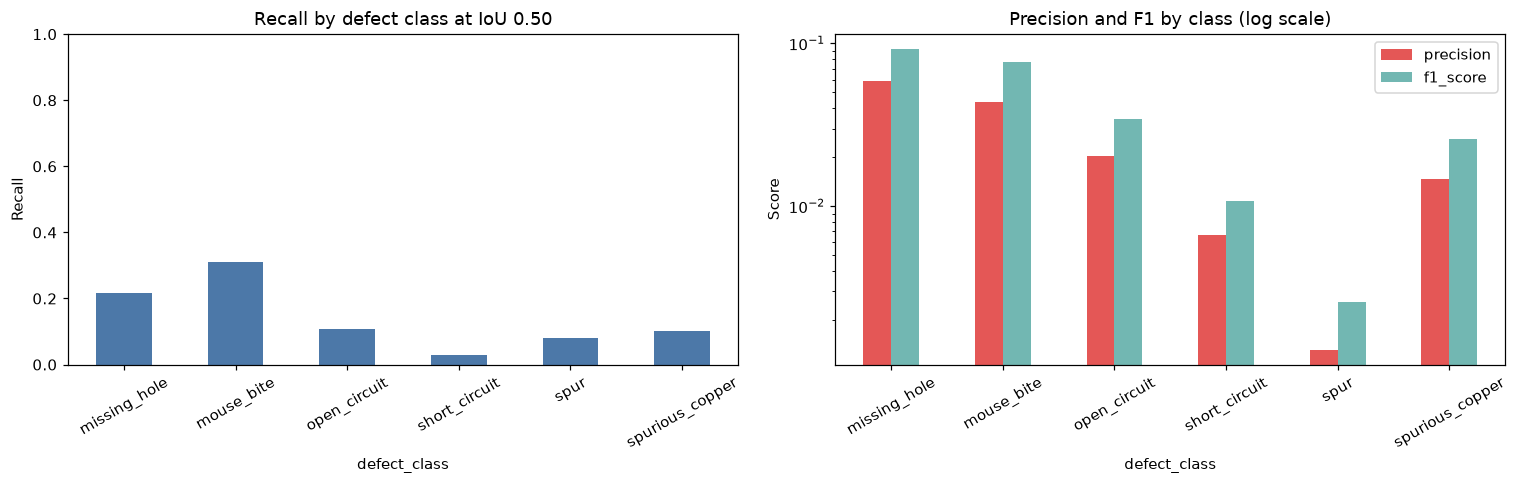

In [8]:
class_metrics_df = pd.DataFrame(summary['box_metrics_by_class']).T
class_metrics_df.index.name = 'defect_class'
display(class_metrics_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
class_metrics_df['recall'].plot.bar(ax=axes[0], color='#4C78A8')
axes[0].set_title('Recall by defect class at IoU 0.50')
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('Recall')
axes[0].tick_params(axis='x', rotation=30)
class_metrics_df[['precision', 'f1_score']].plot.bar(
    ax=axes[1], color=['#E45756', '#72B7B2']
)
axes[1].set_yscale('log')
axes[1].set_title('Precision and F1 by class (log scale)')
axes[1].set_ylabel('Score')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## 5. Template Matching thresholds, fragmentation, and runtime

The threshold plot describes Template Matching's automatic choices; it is not a manual parameter search. Predicted-region counts use a logarithmic scale because raw differences can generate hundreds of thousands of one-pixel or tiny contours.

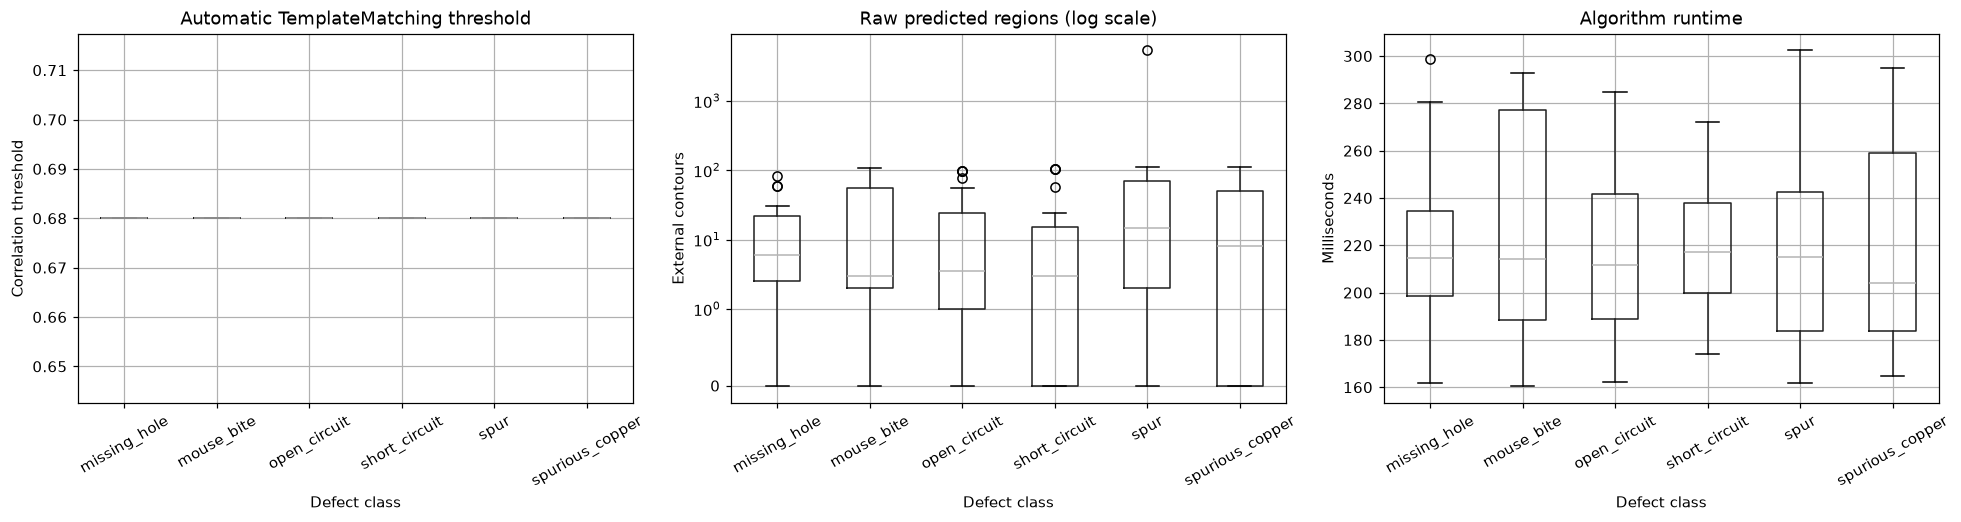

In [9]:
class_order = sorted(results_df['defect_class'].unique())
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
results_df.boxplot(
    column='template_matching_threshold', by='defect_class', ax=axes[0], rot=30
)
axes[0].set_title('Fixed development correlation threshold')
axes[0].set_xlabel('Defect class')
axes[0].set_ylabel('Correlation threshold')
results_df.boxplot(
    column='predicted_count', by='defect_class', ax=axes[1], rot=30
)
axes[1].set_yscale('symlog', linthresh=1)
axes[1].set_title('Raw predicted regions (log scale)')
axes[1].set_xlabel('Defect class')
axes[1].set_ylabel('External contours')
results_df.boxplot(
    column='processing_time_ms', by='defect_class', ax=axes[2], rot=30
)
axes[2].set_title('Algorithm runtime')
axes[2].set_xlabel('Defect class')
axes[2].set_ylabel('Milliseconds')
fig.suptitle('')
plt.tight_layout()
plt.show()

In [10]:
fragmentation_summary = results_df.groupby('defect_class').agg(
    images=('image_id', 'size'),
    median_threshold=('template_matching_threshold', 'median'),
    median_regions=('predicted_count', 'median'),
    maximum_regions=('predicted_count', 'max'),
    mean_runtime_ms=('processing_time_ms', 'mean'),
    recall=('recall', 'mean'),
)
fragmentation_summary

,images,median_threshold,median_regions,maximum_regions,mean_runtime_ms,recall
defect_class,,,,,,
missing_hole,23,0.68,6.0,84,220.435879,0.237681
mouse_bite,23,0.68,3.0,109,224.264167,0.307246
open_circuit,24,0.68,3.5,99,220.682285,0.108333
short_circuit,23,0.68,3.0,105,220.945522,0.031884
spur,23,0.68,15.0,5362,218.844121,0.081159
spurious_copper,23,0.68,8.0,113,217.932324,0.091304


## 6. Per-image results and representative visualisations

In [11]:
result_columns = [
    'image_id', 'defect_class', 'template_matching_threshold', 'predicted_count',
    'ground_truth_count', 'true_positives', 'false_positives',
    'false_negatives', 'precision', 'recall', 'f1_score',
    'mean_matched_iou', 'processing_time_ms',
]
print('Highest matched-IoU development examples')
display(
    results_df.sort_values(
        ['mean_matched_iou', 'recall'], ascending=False
    )[result_columns].head(10)
)
print('Most fragmented development examples')
display(
    results_df.sort_values('predicted_count', ascending=False)[
        result_columns
    ].head(10)
)

Highest matched-IoU development examples


,image_id,defect_class,template_matching_threshold,predicted_count,ground_truth_count,true_positives,false_positives,false_negatives,precision,recall,f1_score,mean_matched_iou,processing_time_ms
32,04_open_circuit_20,open_circuit,0.68,1,3,1,0,2,1.000000,0.333333,0.500000,0.805755,274.116708
20,04_missing_hole_18,missing_hole,0.68,4,3,1,3,2,0.250000,0.333333,0.285714,0.743843,280.620834
18,04_missing_hole_11,missing_hole,0.68,4,3,1,3,2,0.250000,0.333333,0.285714,0.737610,278.253167
75,07_open_circuit_09,open_circuit,0.68,1,5,1,0,4,1.000000,0.200000,0.333333,0.736254,201.742458
2,01_missing_hole_17,missing_hole,0.68,29,3,2,27,1,0.068966,0.666667,0.125000,0.682769,170.852000
114,11_mouse_bite_01,mouse_bite,0.68,106,5,1,105,4,0.009434,0.200000,0.018018,0.675492,187.113458
72,07_mouse_bite_02,mouse_bite,0.68,6,5,3,3,2,0.500000,0.600000,0.545455,0.671495,199.856000
73,07_open_circuit_04,open_circuit,0.68,3,5,2,1,3,0.666667,0.400000,0.500000,0.645653,202.239583
87,08_open_circuit_05,open_circuit,0.68,6,5,1,5,4,0.166667,0.200000,0.181818,0.644531,232.031709
115,11_mouse_bite_05,mouse_bite,0.68,108,5,3,105,2,0.027778,0.600000,0.053097,0.622941,189.566625


Most fragmented development examples


,image_id,defect_class,template_matching_threshold,predicted_count,ground_truth_count,true_positives,false_positives,false_negatives,precision,recall,f1_score,mean_matched_iou,processing_time_ms
66,06_spur_08,spur,0.68,5362,5,1,5361,4,0.000186,0.2,0.000373,0.545229,243.613750
128,11_spurious_copper_08,spurious_copper,0.68,113,5,0,113,5,0.000000,0.0,0.000000,0.000000,184.881333
125,11_spur_09,spur,0.68,112,5,0,112,5,0.000000,0.0,0.000000,0.000000,183.932292
126,11_spurious_copper_02,spurious_copper,0.68,109,5,3,106,2,0.027523,0.6,0.052632,0.529119,184.546125
116,11_mouse_bite_06,mouse_bite,0.68,109,5,4,105,1,0.036697,0.8,0.070175,0.545057,186.777875
115,11_mouse_bite_05,mouse_bite,0.68,108,5,3,105,2,0.027778,0.6,0.053097,0.622941,189.566625
127,11_spurious_copper_04,spurious_copper,0.68,106,5,1,105,4,0.009434,0.2,0.018018,0.608855,183.352500
114,11_mouse_bite_01,mouse_bite,0.68,106,5,1,105,4,0.009434,0.2,0.018018,0.675492,187.113458
122,11_short_09,short_circuit,0.68,105,5,0,105,5,0.000000,0.0,0.000000,0.000000,185.745000
123,11_spur_01,spur,0.68,104,5,0,104,5,0.000000,0.0,0.000000,0.000000,184.041417


In [12]:
def show_development_result(image_id, maximum_drawn_boxes=500):
    manifest_row = development_df.loc[
        development_df['image_id'].eq(image_id)
    ].iloc[0]
    result_row = results_df.loc[results_df['image_id'].eq(image_id)].iloc[0]
    reference = load_image(PROJECT_ROOT / manifest_row['reference_path'])
    defective = load_image(PROJECT_ROOT / manifest_row['image_path'])
    ground_truth = parse_voc_boxes(
        PROJECT_ROOT / manifest_row['annotation_path']
    )
    detection = detect_template_matching(
        reference, defective, BLOCK_SIZE, STEP_SIZE, CORR_THRESHOLD
    )
    overlay = defective.copy()

    for box in ground_truth:
        cv2.rectangle(
            overlay,
            (int(box['xmin']), int(box['ymin'])),
            (int(box['xmax']), int(box['ymax'])),
            (0, 0, 255),
            4,
        )
    boxes_drawn = len(detection.boxes) <= maximum_drawn_boxes
    if boxes_drawn:
        for box in detection.boxes:
            cv2.rectangle(
                overlay,
                (int(box['xmin']), int(box['ymin'])),
                (int(box['xmax']), int(box['ymax'])),
                (0, 255, 0),
                2,
            )

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].imshow(cv2.cvtColor(reference, cv2.COLOR_BGR2RGB))
    axes[0].set_title('Reference')
    axes[1].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    overlay_note = 'GT red; predictions green' if boxes_drawn else 'GT red; boxes omitted from display'
    axes[1].set_title(overlay_note)
    
    
    axes[2].imshow(detection.mask, cmap='gray')
    axes[2].set_title(f"Raw mask; NCC Threshold={detection.corr_threshold:.2f} | {int(result_row['predicted_count']):,} blocks")
    for axis in axes:
        axis.axis('off')
    fig.suptitle(
        f"{image_id} | class={manifest_row['defect_class']} | "
        f"recall={result_row['recall']:.3f} | "
        f"mean matched IoU={result_row['mean_matched_iou']:.3f}"
    )
    plt.tight_layout()
    plt.show()

    return result_row[result_columns].to_frame(name='value')

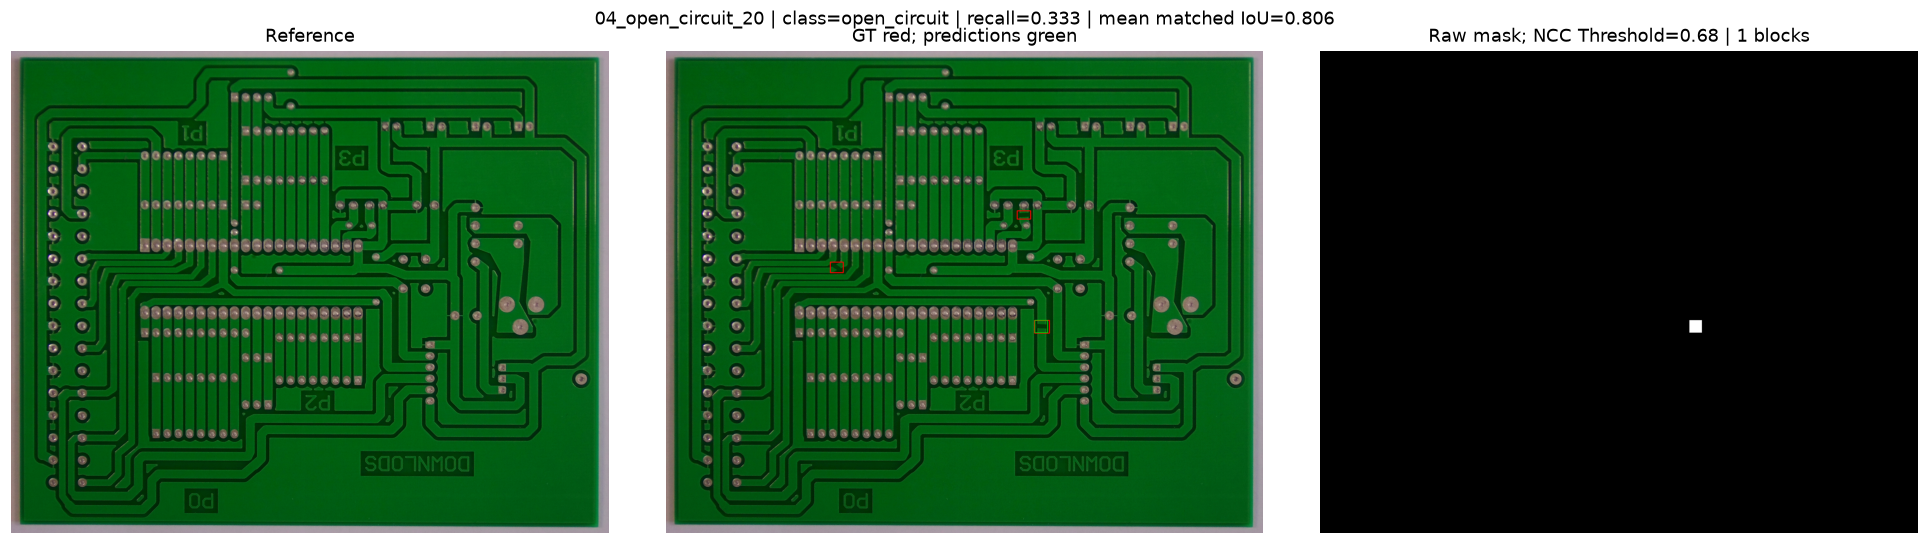

,value
image_id,04_open_circuit_20
defect_class,open_circuit
template_matching_threshold,0.68
predicted_count,1
ground_truth_count,3
true_positives,1
false_positives,0
false_negatives,2
precision,1.0
recall,0.333333


In [13]:
best_image_id = results_df.sort_values(
    ['mean_matched_iou', 'recall'], ascending=False
).iloc[0]['image_id']
show_development_result(best_image_id)

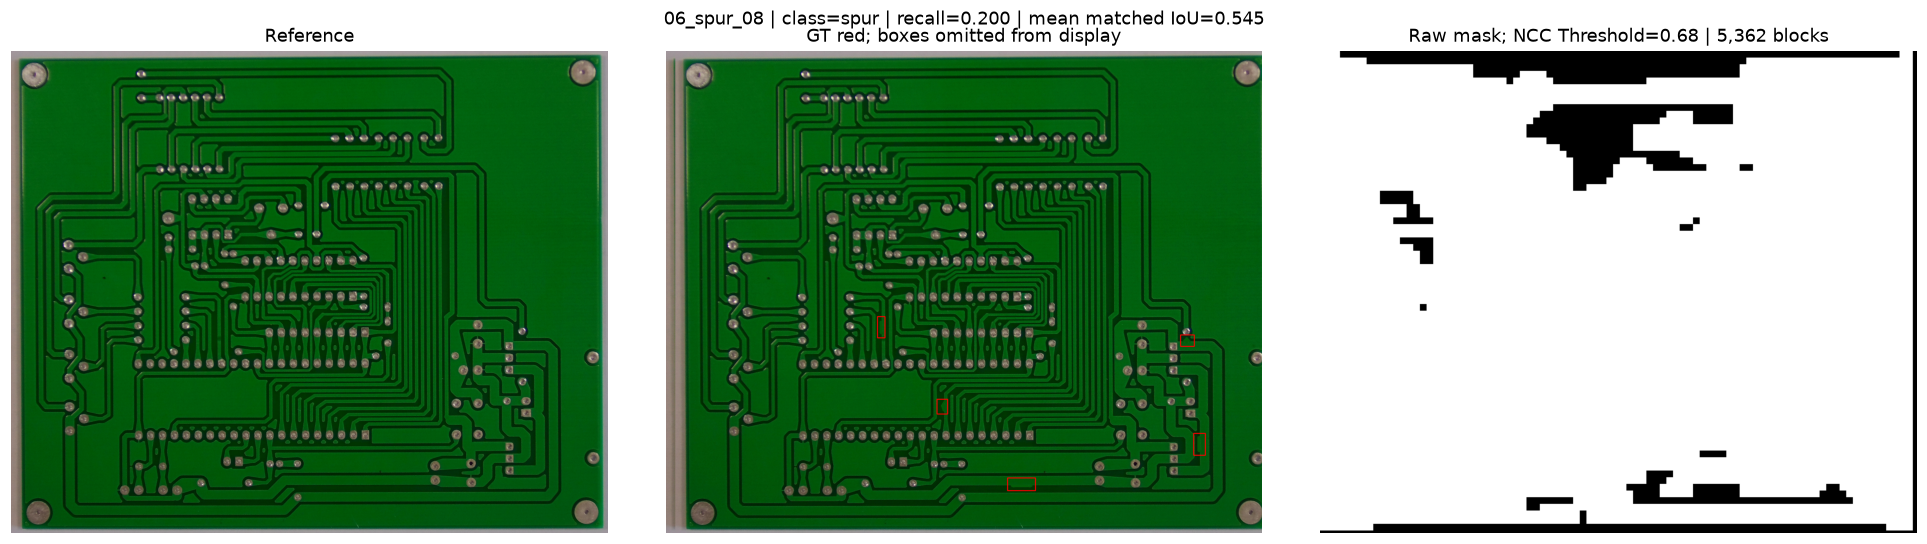

,value
image_id,06_spur_08
defect_class,spur
template_matching_threshold,0.68
predicted_count,5362
ground_truth_count,5
true_positives,1
false_positives,5361
false_negatives,4
precision,0.000186
recall,0.2


In [14]:
most_fragmented_image_id = results_df.sort_values(
    'predicted_count', ascending=False
).iloc[0]['image_id']
show_development_result(most_fragmented_image_id)

## 7. Development conclusion

Raw Template Matching uses a fixed development baseline of 64×64 blocks, stride 32, and correlation threshold 0.68. These are candidates, not validation-frozen winners. Compare correlation threshold, block size, and stride candidates on validation, then freeze the selected configuration before running the test split. The experiment intentionally forbids smoothing, merging, filtering, and non-maximum suppression.